# Task 3: Modeling and Evaluation, Breast Tumor Classification Baseline

**Goal:** build a baseline classifier, compare it with simple models, evaluate it with metrics suited to the problem, and discuss limitations.

**Dataset:** Wisconsin Diagnostic Breast Cancer (bundled with scikit-learn, so no download or API key is needed). Each row is a tumor described by 30 measurements from a digitized image of a fine-needle aspirate; the label says whether it is malignant or benign.

**Why the metric choice matters:** in screening, missing a malignant tumor (false negative) is far more costly than flagging a benign one for follow-up (false positive). So I treat *malignant* as the positive class and look at **recall**, **precision**, **F1** and **ROC-AUC**, not accuracy alone.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, roc_auc_score, recall_score, precision_score, f1_score)

import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)  # dummy model never predicts "malignant", so its precision is undefined (reported as 0)

RANDOM_STATE = 42
data = load_breast_cancer(as_frame=True)
X = data.data
y = (data.target == 0).astype(int)   # 1 = malignant (positive class), 0 = benign
print("Shape:", X.shape)
print("Malignant share: %.1f%%" % (100 * y.mean()))
print("Missing values:", int(X.isna().sum().sum()))

Shape: (569, 30)
Malignant share: 37.3%
Missing values: 0


## 1. Split the data

A stratified 80/20 split keeps the malignant/benign ratio the same in train and test. The test set is held out and used **once**, at the end.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Malignant share  train: %.3f  test: %.3f" % (y_train.mean(), y_test.mean()))

Train: (455, 30)  Test: (114, 30)
Malignant share  train: 0.374  test: 0.368


## 2. Baseline and candidate models

The **baseline** is a dummy classifier that always predicts the majority class (benign). Any real model has to beat it. I then compare two simple models using 5-fold stratified cross-validation on the training set only.

In [3]:
models = {
    "Dummy (majority class)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = {}
for name, model in models.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    rows[name] = {m: (res["test_" + m].mean(), res["test_" + m].std()) for m in scoring}

cv_table = pd.DataFrame({n: {m: "%.3f ± %.3f" % v for m, v in r.items()} for n, r in rows.items()}).T
print(cv_table.to_string())

                             accuracy      precision         recall             f1        roc_auc
Dummy (majority class)  0.626 ± 0.000  0.000 ± 0.000  0.000 ± 0.000  0.000 ± 0.000  0.500 ± 0.000
Logistic Regression     0.974 ± 0.015  0.977 ± 0.028  0.953 ± 0.040  0.964 ± 0.021  0.996 ± 0.005
Random Forest           0.960 ± 0.016  0.958 ± 0.022  0.935 ± 0.039  0.946 ± 0.023  0.988 ± 0.007


## 3. Final evaluation on the held-out test set

I pick logistic regression as the working model: it is competitive, fast, and interpretable, which is a good property for a baseline. It is fit on the full training set and scored once on the test set.

In [4]:
final = models["Logistic Regression"].fit(X_train, y_train)
pred = final.predict(X_test)
proba = final.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred, target_names=["benign", "malignant"], digits=3))
print("ROC-AUC: %.3f" % roc_auc_score(y_test, proba))

dummy = models["Dummy (majority class)"].fit(X_train, y_train)
print("Dummy baseline test accuracy: %.3f, malignant recall: %.3f" % (
    dummy.score(X_test, y_test), recall_score(y_test, dummy.predict(X_test))))

              precision    recall  f1-score   support

      benign      0.959     0.986     0.973        72
   malignant      0.975     0.929     0.951        42

    accuracy                          0.965       114
   macro avg      0.967     0.957     0.962       114
weighted avg      0.965     0.965     0.965       114

ROC-AUC: 0.996
Dummy baseline test accuracy: 0.632, malignant recall: 0.000


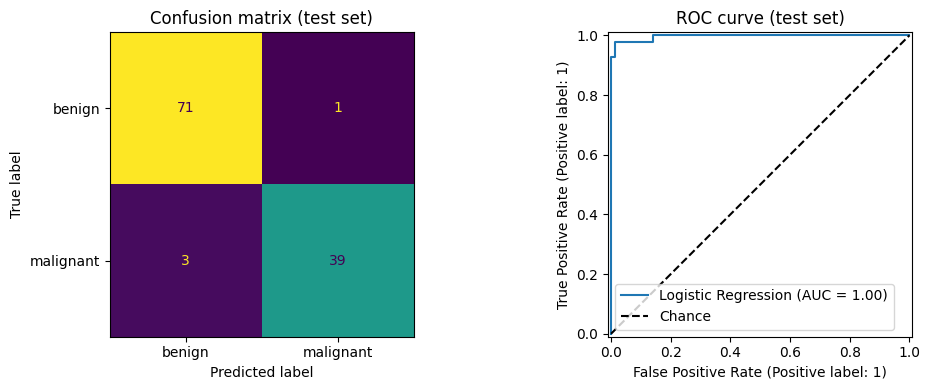

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["benign", "malignant"]).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Confusion matrix (test set)")
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1], name="Logistic Regression")
ax[1].plot([0, 1], [0, 1], "k--", label="Chance")
ax[1].legend(); ax[1].set_title("ROC curve (test set)")
plt.tight_layout(); plt.show()

## 4. Error analysis and the precision/recall trade-off

Because missed malignant cases are the costly error, I look at lowering the decision threshold below 0.5. To avoid tuning on the test set (which would leak information and inflate results), the threshold is chosen from **out-of-fold predictions on the training set only**, then applied to the test set once.

In [6]:
from sklearn.model_selection import cross_val_predict

oof = cross_val_predict(models["Logistic Regression"], X_train, y_train, cv=cv, method="predict_proba")[:, 1]

def threshold_table(y_true, p, thresholds):
    out = []
    for t in thresholds:
        pred_t = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred_t).ravel()
        out.append({"threshold": t, "recall": recall_score(y_true, pred_t),
                    "precision": precision_score(y_true, pred_t), "FN": fn, "FP": fp})
    return pd.DataFrame(out).round(3)

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]
print("Out-of-fold results on the TRAINING set:")
print(threshold_table(y_train, oof, thresholds).to_string(index=False))

Out-of-fold results on the TRAINING set:
 threshold  recall  precision  FN  FP
       0.5   0.953      0.976   8   4
       0.4   0.965      0.965   6   6
       0.3   0.976      0.954   4   8
       0.2   0.982      0.923   3  14
       0.1   0.988      0.862   2  27


In [7]:
# Rule fixed in advance: the highest threshold whose out-of-fold recall is at least 0.97
tt = threshold_table(y_train, oof, thresholds)
chosen = tt[tt["recall"] >= 0.97]["threshold"].max()
print("Chosen threshold:", chosen)

print("\nTEST set, default vs chosen threshold:")
print(threshold_table(y_test, proba, [0.5, chosen]).to_string(index=False))

Chosen threshold: 0.3

TEST set, default vs chosen threshold:
 threshold  recall  precision  FN  FP
       0.5   0.929      0.975   3   1
       0.3   0.976      0.976   1   1


In [8]:
coef = pd.Series(final[-1].coef_[0], index=X.columns).sort_values()
print("Most negative coefficients (push toward benign):")
print(coef.head(3).round(2).to_string())
print("\nMost positive coefficients (push toward malignant):")
print(coef.tail(3).round(2).to_string())

Most negative coefficients (push toward benign):
compactness error         -0.91
fractal dimension error   -0.59
mean compactness          -0.44

Most positive coefficients (push toward malignant):
worst symmetry    1.06
radius error      1.23
worst texture     1.43


## 5. Results summary

| Model | CV recall (malignant) | CV F1 | CV ROC-AUC |
|---|---|---|---|
| Dummy (majority class) | 0.000 | 0.000 | 0.500 |
| Logistic Regression | 0.953 | 0.964 | 0.996 |
| Random Forest | 0.935 | 0.946 | 0.988 |

On the held-out test set, logistic regression reached 96.5% accuracy, 0.996 ROC-AUC, and 0.929 malignant recall at the default 0.5 threshold (3 missed malignant cases out of 42). Lowering the threshold to 0.3, chosen using only training-set out-of-fold predictions, raised recall to 0.976 (1 missed case) with no extra false positives on this test set.

The dummy baseline scores 63% accuracy while catching **zero** malignant tumors. This is why accuracy alone would be a misleading metric here.

## 6. Limitations

- **Small, clean, single-source dataset.** 569 rows from one collection, with no missing values. Real clinical data is messier, and results like a 0.996 AUC rarely carry over to new hospitals, scanners, or patient populations. There is no external validation set here.
- **High variance from the small test set.** The test set has only 42 malignant cases, so a single patient changes recall by about 2.4 percentage points. The move from 3 to 1 missed cases at the lower threshold is encouraging but not statistically strong evidence. Repeated cross-validation or a larger dataset would give tighter estimates.
- **Threshold choice encodes a cost judgment.** The 0.97 recall target was picked by me for illustration. In practice the acceptable trade-off between false negatives and false positives should come from clinicians, and the cost of each error type should be quantified.
- **Coefficients should not be over-read.** Many of the 30 features are strongly correlated (for example radius, perimeter and area), so individual logistic regression coefficients are unstable and are not causal effects.
- **Limited model search.** Models were used with mostly default settings and no hyperparameter tuning or calibration check. The Random Forest ranking below logistic regression may change with tuning.
- **Not a clinical tool.** This is a learning exercise. It has not been validated for medical use, and it ignores fairness, subgroup performance, and dataset shift.

## 7. Possible next steps

Tune hyperparameters with nested cross-validation, check probability calibration, test on a second dataset for external validation, and report confidence intervals (for example by bootstrapping) for each metric.